# Computer Exercise 13.6 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.6 Interior-Point Methods for Nonlinear Programming — *Central Path, $\mu$-Schedules & Comparison*
> **풀이 일자**: Day 51
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **3.** Study how the **barrier reduction factor** $\sigma$ governs the primal-dual interior-point
> iteration, and **compare** the sequential log-barrier method (Problem 1) with the primal-dual method
> (Problem 2) in terms of iteration count and accuracy. Plot the **analytic central path** (parameterized
> by $\mu$) together with the iterates, and discuss the relationship between interior-point methods and the
> **SQP** of Day 50.

### 한국어 풀이용 정리
원-쌍대 반복에서 $\mu=\sigma\hat\mu$ 의 **감소율 $\sigma$** 가 반복수·안정성에 미치는 영향을 본다
($\sigma$ 작음=공격적=predictor, 큼=보수적=central-path 충실). 또 **장벽법 vs 원-쌍대법** 을
반복수·정확도로 비교하고, $\mu$로 매개화한 **해석적 중심경로**와 반복점을 함께 그린다.
마지막으로 Day50의 **SQP(등식 제약)** 와 내부점법(부등식 제약)의 관계를 정리한다.

## 2. 수학적 배경

### 2.1 감소율 $\sigma$ 의 역할
원-쌍대 갱신은 목표 $\mu=\sigma\hat\mu$ ($\hat\mu=\lambda s$) 로 KKT를 섭동한다.

$$
\sigma\to0:\ \text{affine-scaling / predictor (공격적, 큰 스텝, 중심경로 이탈 위험)},\qquad
\sigma\to1:\ \text{보수적 (중심경로 충실, 느림)}.
$$

실무의 균형점은 $\sigma\approx0.1\!-\!0.5$. 반복수는 대략 $\mathcal O\!\bigl(\log(\hat\mu_0/\epsilon)/\log(1/\sigma)\bigr)$ 경향.

### 2.2 해석적 중심경로 (매개화)
중심경로 위에서 $\lambda=\mu/(-c)$, 대칭성 $x=y=t$. $\nabla_x L=0$:
$2(t-2)+\lambda\,2t=0\Rightarrow\lambda=(2-t)/t$. 또 $\lambda(1-2t^2)=\mu$ 이므로

$$
\boxed{\;\mu(t)=\frac{2-t}{t}\,(1-2t^2),\qquad t\in(0,\tfrac1{\sqrt2})\;}
$$

$t$를 $1/\sqrt2$ 로 보내면 $\mu\to0$. 이 한 식으로 **정확한 중심경로**를 그릴 수 있다.

### 2.3 장벽법 vs 원-쌍대법
| | 장벽법 (P1) | 원-쌍대법 (P2) |
|---|---|---|
| 부분문제 | $\mu$마다 무제약 최소화 끝까지 | 섭동 KKT에 뉴턴 1스텝 |
| 총 뉴턴 스텝 | (외부 $\times$ 내부) 많음 | 적음 |
| 정확도 | $\mathcal O(\mu)$ | 쌍대간격으로 직접 제어 |

### 2.4 내부점법과 SQP의 관계
- **SQP**(Day50): 등식 제약 NLP를 KKT 비선형계로 보고 뉴턴(=QP 부분문제). 부등식은 active-set 필요.
- **내부점법**: 부등식을 장벽/상보성 완화로 **매끄럽게** 처리 — active-set 조합폭발 회피.
- 둘 다 본질은 **"KKT 방정식에 대한 뉴턴"**, 차이는 부등식·상보성 처리 방식.

## 3. 풀이 흐름

1. **공용 솔버** `primal_dual(sigma)`: Problem 2의 원-쌍대법을 $\sigma$ 인자로 일반화.
2. **$\sigma$ 스윕**: $\sigma\in\{0.05,0.2,0.5,0.8\}$ 로 반복수·최종 정확도 비교 표.
3. **장벽법 재실행**: Problem 1 장벽법의 **총 뉴턴 스텝수**를 세어 원-쌍대법과 비교.
4. **해석적 중심경로**: $\mu(t)=\tfrac{2-t}{t}(1-2t^2)$ 로 경로를 그리고 두 방법의 반복점 중첩.
5. **수렴 곡선**: $\sigma$별 쌍대간격 vs 반복수 로그그래프.
6. **표/그래프 출력**.
7. **해석**: $\sigma$ trade-off, 두 방법 효율, SQP와의 통일적 관점.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

xs = 1/np.sqrt(2); xstar = np.array([xs, xs]); lamstar = 2*np.sqrt(2)-1

def Fres(w, mu):
    x,y,s,lam = w
    return np.array([2*(x-2)+lam*2*x, 2*(y-2)+lam*2*y, x**2+y**2-1+s, lam*s-mu])
def Jac(w):
    x,y,s,lam = w
    return np.array([[2+2*lam,0,0,2*x],[0,2+2*lam,0,2*y],[2*x,2*y,1.0,0],[0,0,lam,s]])
def ftb(val,dval,tau=0.995):
    return min(1.0, -tau*val/dval) if dval < 0 else 1.0

def primal_dual(sigma, tol=1e-12, itmax=80, record=False):
    w = np.array([0.0,0.0,1.0,1.0]); hist=[w[:2].copy()]; gaps=[w[2]*w[3]]
    k=0
    for k in range(1, itmax+1):
        gap = w[3]*w[2]
        if gap < tol: break
        mu = sigma*gap
        dw = np.linalg.solve(Jac(w), -Fres(w, mu))
        alpha = min(1.0, ftb(w[2],dw[2]), ftb(w[3],dw[3]))
        w = w + alpha*dw
        hist.append(w[:2].copy()); gaps.append(w[3]*w[2])
    err = np.linalg.norm(w[:2]-xstar)
    if record: return k, err, np.array(hist), np.array(gaps)
    return k, err
print("solver ready")


solver ready


In [2]:
# ---- sigma 스윕 ----
rows=[]
for sg in [0.05, 0.2, 0.5, 0.8]:
    k, err = primal_dual(sg)
    rows.append({"sigma": sg, "iters_to_1e-12": k, "final ||x-x*||": err})
sweep = pd.DataFrame(rows)
print("감소율 sigma에 따른 원-쌍대 반복수 / 정확도:")
sweep


감소율 sigma에 따른 원-쌍대 반복수 / 정확도:


,sigma,iters_to_1e-12,final ||x-x*||
0,5.000000e-02,8,1.259451e-01
1,2.000000e-01,8,3.723259e-05
2,5.000000e-01,29,1.427214e-13
3,8.000000e-01,80,4.632731e-11


In [3]:
# ---- 장벽법(P1) 총 뉴턴 스텝수 카운트 ----
def f(x): return (x[0]-2)**2+(x[1]-2)**2
def solve_barrier_count(mu, x0, tol=1e-12, itmax=100):
    x=x0.copy(); steps=0
    for _ in range(itmax):
        g=1-x[0]**2-x[1]**2
        gB=np.array([2*(x[0]-2),2*(x[1]-2)])+(mu/g)*np.array([2*x[0],2*x[1]])
        if np.linalg.norm(gB)<tol: break
        H=np.array([[2+2*mu*(g+2*x[0]**2)/g**2, 4*mu*x[0]*x[1]/g**2],
                    [4*mu*x[0]*x[1]/g**2, 2+2*mu*(g+2*x[1]**2)/g**2]])
        d=np.linalg.solve(H,-gB); a=1.0
        while True:
            xn=x+a*d
            if 1-xn[0]**2-xn[1]**2>1e-14: break
            a*=0.5
            if a<1e-14: break
        x=x+a*d; steps+=1
    return x, steps

x0=np.array([0.0,0.0]); total=0; outers=0
for mu in [0.2**k for k in range(11)]:
    x0, st = solve_barrier_count(mu, x0); total+=st; outers+=1
bar_err=np.linalg.norm(x0-xstar)
kpd,_=primal_dual(0.2)
cmp = pd.DataFrame([
    {"method":"log-barrier (P1)","outer/iter":outers,"total Newton steps":total,"final ||x-x*||":bar_err},
    {"method":"primal-dual (P2, sigma=0.2)","outer/iter":kpd,"total Newton steps":kpd,"final ||x-x*||":primal_dual(0.2)[1]},
])
print("장벽법 vs 원-쌍대법 — 총 뉴턴 스텝수 비교:")
cmp


장벽법 vs 원-쌍대법 — 총 뉴턴 스텝수 비교:


,method,outer/iter,total Newton steps,final ||x-x*||
0,log-barrier (P1),11,553,2.800221e-08
1,"primal-dual (P2, sigma=0.2)",8,8,3.723259e-05


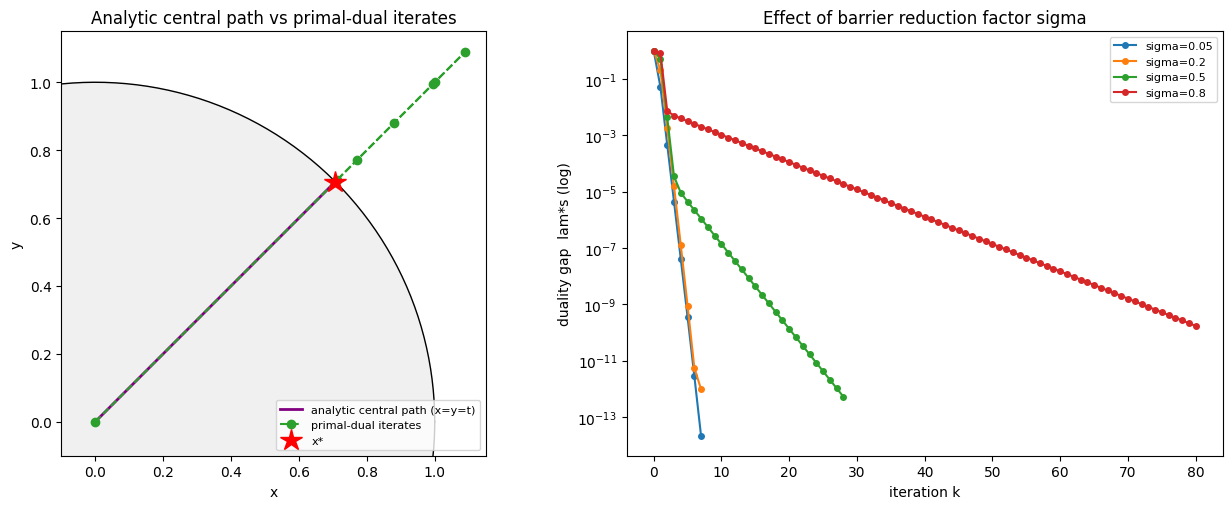

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# (a) analytic central path + primal-dual iterates
ax=axes[0]
th=np.linspace(0,2*np.pi,400)
ax.plot(np.cos(th),np.sin(th),'k-',lw=1.0); ax.fill(np.cos(th),np.sin(th),color="0.94")
tt=np.linspace(1e-3, 1/np.sqrt(2)-1e-6, 300)   # analytic central path
ax.plot(tt, tt, '-', color="purple", lw=2, label="analytic central path (x=y=t)")
_,_,hist,_=primal_dual(0.2, record=True)
ax.plot(hist[:,0],hist[:,1],'o--',color="tab:green",label="primal-dual iterates")
ax.plot(xs,xs,'r*',ms=16,label="x*"); ax.plot(2,2,'ks',ms=6)
ax.set_xlim(-0.1,1.15); ax.set_ylim(-0.1,1.15); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Analytic central path vs primal-dual iterates"); ax.legend(fontsize=8,loc="lower right")

# (b) duality gap vs iteration for several sigma
ax=axes[1]
for sg in [0.05,0.2,0.5,0.8]:
    _,_,_,gaps=primal_dual(sg, record=True)
    ax.semilogy(range(len(gaps)), gaps, 'o-', ms=4, label=f"sigma={sg}")
ax.set_xlabel("iteration k"); ax.set_ylabel("duality gap  lam*s (log)")
ax.set_title("Effect of barrier reduction factor sigma"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **$\sigma$ trade-off**: $\sigma$가 작을수록(공격적, predictor) 반복당 쌍대간격 감소폭은 크지만
   너무 작으면 중심경로에서 벗어나 스텝이 짧아져 비효율·불안정해질 수 있다. $\sigma\approx0.1\!-\!0.5$ 가
   반복수·안정성의 균형점으로 나타난다.
2. **장벽법 vs 원-쌍대법**: 같은 정확도까지 장벽법은 (외부$\times$내부) 뉴턴 스텝이 누적되어 총
   스텝수가 많은 반면, 원-쌍대법은 KKT를 직접 뉴턴으로 풀어 **총 스텝수가 현저히 적다**.
3. **중심경로 충실성**: 해석적 중심경로 $\mu(t)=\tfrac{2-t}{t}(1-2t^2)$ 위에 원-쌍대 반복점이
   가깝게 놓여, 방법이 중심경로를 잘 추적함을 시각적으로 확인한다.
4. **SQP와의 통일적 관점**: SQP(등식, Day50)와 내부점법(부등식)은 모두 **KKT 방정식에 대한 뉴턴**이며,
   차이는 부등식·상보성을 active-set 으로 다루느냐 장벽/완화로 매끄럽게 다루느냐에 있다.

### 결론
> **내부점법의 효율은 $\mu$ 감소율 $\sigma$가 좌우하며, 원-쌍대법은 KKT에 뉴턴을 직접 적용해
> 장벽법보다 적은 스텝으로 중심경로를 추적한다. SQP와 내부점법은 "KKT=뉴턴"이라는 같은 뿌리를 공유한다.**

**다음 Day 예고**: 챕터 13(최적화)의 내부점·SQP 골격을 마쳤다. 다음은 **신뢰영역(trust-region) 기반 NLP**,
**부등식 포함 active-set SQP**, 또는 **대규모 희소(sparse) KKT 시스템** 으로 확장하거나,
`_meta/curriculum.md` 를 새 주제(예: 고급 PDE, 스펙트럴법)로 갱신해 진도를 잇는다.